In [1]:
from scipy.linalg import block_diag
from simulation.camera_model import get_K, get_camera_pose
from simulation.scene_generator import PointsGenerator
from simulation.projection import  project_points,filter_visible
import matplotlib.pyplot as plt

# Core functions

In [2]:
import numpy as np
from normalization import normalize
from scipy.linalg import block_diag
from scipy.optimize import least_squares

def linear_eq(points1, points2):
    """
    Function to construct the matrix A used to solve the epipolar constraint equation x'TFx = 0, 
    where Af = 0
    Input:
        - points1: 2Dpoints of the first image (np.array of size Nx2 or Nx3)
        - points2: 2Dpoints of the second image (np.array of size Nx2 or Nx3)
    Output:
        - A: The linear system equation (np.array of size Nx9)
    """
    # Determine the number of point correspondences
    length = min(points1.shape[0], points2.shape[0])
    
    # Initialize the design matrix A (N x 9) for the equation Af = 0
    A = np.zeros((length, 9))
    for i in range(length):
        A[i, 0] = points2[i, 0]*points1[i, 0]
        A[i, 1] = points2[i, 0]*points1[i, 1]
        A[i, 2] = points2[i, 0]
        A[i, 3] = points2[i, 1]*points1[i, 0]
        A[i, 4] = points2[i, 1]*points1[i, 1]
        A[i, 5] = points2[i, 1]
        A[i, 6] = points1[i, 0]
        A[i, 7] = points1[i, 1]
        A[i, 8] = 1
    return A

def eight_point1(points1, points2):
    """
    Function to execute the normalized 8-points algorithm to determine the fundamental matrix F
    Input:
        - points1: 2D homogenous points of the first image - pixel coordinates (np.array of size Nx3)
        - points2: 2D homogenous points of the second image - pixel coordinates (np.array of size Nx3)
    Output:
        - F: Fundamental matrix (np.array 3x3)
    """
    #1: Normalization: increase stability
    T1 = normalize(points1) # Normalization matrix
    T2 = normalize(points2)
    norm1 = (T1 @ points1.T).T
    norm2 = (T2 @ points2.T).T

    #2: Find the fundamental matrix of the normalized points
    A_hat = linear_eq(norm1, norm2) # Normalized linear system where A_hat*f_hat = 0
    U, S, Vh = np.linalg.svd(A_hat)
    F_hat = Vh[-1, :].reshape(3, 3)

    #3: Replace F_hat but Fprime_hat such that det Fprime_hat = 0
    U1, S1, Vh1 = np.linalg.svd(F_hat)
    S1[2] = 0
    Fprime_hat = U1@np.diag(S1)@Vh1
    
    #4: Mminimize algebriac error and denormalize
    F_hat_opt = min_alg_error(Fprime_hat, A_hat)
    F = T2.T@F_hat_opt@T1

    return F

def min_alg_error(F0, A):
    """
    Function which calculate the fundamental matrix by minimizing the algebraic error.
    Input:
        - F0: Inital guess of the fundamentral matrix (np.array of size 3x3)
        - A: Linear system equation (np.array of size Nx9)
    Ouput:
        - F_opt: Optimal fundamental matrix (np.array of size 3x3)
    """
    
    # Find the right null space e0 of F0 (the initial epipole guess)
    U, S, Vh = np.linalg.svd(F0)
    e0 = Vh[-1, :] #Last row of Vh
    tracker = {'prev_epsilon': None} # Tracker to prevent the SVD sign-flipping issue between LM iterations
    
    # Run Levenberg-Marquardt to optimize the epipole coordinates
    result = least_squares(
        fun=residual_fun, # Cost function
        x0=e0, # Initial guess
        args=(A, tracker),  
        method='lm',
        xtol=1e-15,  
        ftol=1e-15   
    )

    # Reconstruct the optimized Fundamental matrix using the optimal epipole
    e_opt = result.x
    ex = np.array([
        [0,        -e_opt[2],  e_opt[1]],
        [e_opt[2],  0,        -e_opt[0]],
        [-e_opt[1], e_opt[0],  0       ]
    ])
    E_opt = block_diag(ex, ex, ex)
    
    # Get final 9-element vector and reshape to 3x3
    f_opt = constrained_min(A, E_opt)
    F_opt = f_opt.reshape(3, 3)
    
    return F_opt

def constrained_min(A, G):
    """
    Function which solves x that minimizes ||Ax|| subject to x = G*x_hat and ||x|| = 1
    Input: 
        - A: The linear system equation (np.array of size Nx9)
        - G: Block-diagonal constraint matrix built from the skew-symmetric matrix of the epipole
             (np.array of size 9x9)
    Ouput:
        - x: Best-fit Fundamental Matrix for that specific epipole (vector of size 9)
    """
    # Find the valid parameter subspace defined by G
    U, S, Vh = np.linalg.svd(G)
    r = np.linalg.matrix_rank(G) # Determine true degrees of freedom
    U_prime = U[:,:r] # Extract basis for the subspace
    
    # Solve the reduced system
    _, _, Vh2 = np.linalg.svd(A @ U_prime)
    x_prime = Vh2[-1, :] # The minimizer in the reduced space
    # Project back to the original 9D space
    x = U_prime@x_prime
    return x

def residual_fun(e, A, state):
    """
    Cost function to be implemented in the LM algorithm which calculates how much 
    error is produced by a specific guess for the epipole.
    Input:
        - e: Current guess of the epipole coordinates (vector of size 3)
        - A: Linear system equation (np.array Nx9)
        - state: Tracker for the previous error (dictionnary)
    Output:
        - epsilon: Algebraic error residuals (np.array of size 1x1)
    """
    # Objective function evaluated at every LM iteration

    # Build skew-symmetric matrix of current epipole guess  
    ex = np.array([
        [0,    -e[2],  e[1]],
        [e[2],  0,    -e[0]],
        [-e[1], e[0],  0   ]
    ])
    
    # Constraint matrix E ensuring F*e = 0
    E = block_diag(ex, ex, ex)
    f = constrained_min(A, E)

    # Compute current algebraic error vector
    epsilon = A@f

    # Enforce smooth sign variation to prevent SVD from flipping directions randomly
    if state['prev_epsilon'] is not None:
        dot_product = np.dot(epsilon, state['prev_epsilon'])
        if dot_product < 0:
            epsilon = -epsilon # Flip sign if pointing the opposite way from last step
    state['prev_epsilon'] = epsilon.copy() # Save current error for the next iteration

    return epsilon

def get_R_t_from_F1(F, K):
    """
    Function to retrieve the rotational matrix and translational matrix 
    given the fundamental matrix, assuming P = [I|0] and P' = [R|t]
    Input:
        - F: Fundamental matrix (3x3, np.array)
        - K: Intrinsic matrix (3x3, np.array)
    Ouput:
        - t:  Translational matrix
        - R1: Rotational matrix (option 1)
        - R2: Rotational matrix (option 2)
    """
    
    # Calculate Essential matrix from Fundamental matrix and Intrinsics
    E = K.T@F@K 
    
    # Standard orthogonal matrices used for decomposing E
    W = np.array([
        [0, -1, 0],
        [1, 0, 0],
        [0, 0, 1]
    ])
    
    # Decompose the Essential matrix
    U, S, Vh = np.linalg.svd(E)
    print(f"Sigma = {S}")

    # The translation is the last column of U (left null space)
    t = U[:, 2].reshape(-1, 1) 
    
    # Two possible rotation matrices
    R1 = U@W@Vh
    R2 = U@W.T@Vh

    # Ensure they are valid rotation matrices (det = +1, not -1, to prevent reflections)
    if np.linalg.det(R1) < 0: R1 = -R1
    if np.linalg.det(R2) < 0: R2 = -R2

    return t, R1, R2

def P_estimation(t, R1, R2, K, s):
    """
    Function which assembles the four possible solution of the projection matrices (P' = K[R | t]).
    Input:
        - t: Estimate of the translation unit vector (np.array of size 3x1)
        - R1: Estimate of the rotation matrix - option n°1 (np.array of size 3x3)
        - R2: Estimate of the rotation matrix - option n°2 (np.array of size 3x3)
        - K: Intrinsic parameter matrix (np.array of size 3x3)
        - s: Scaling factor to convert the unit vector 't' to actual distance
    Output:
        - P_est: Stack containing all the possible projection matrices (np.array of size 4x3x4)
    """

    P_est1 = K@np.hstack((R1, s*t)) # Rotation 1, Positive translation
    P_est2 = K@np.hstack((R1, -s*t)) # Rotation 1, Negative translation
    P_est3 = K@np.hstack((R2, s*t)) # Rotation 2, Positive translation
    P_est4 = K@np.hstack((R2, -s*t)) # Rotation 2, Negative translation

    # Stacking all the possible projection matrices
    P_est = np.stack([P_est1, P_est2, P_est3, P_est4])
    return P_est

def reprojection_error(P, points_2d, points_3d):
    """
    Calcule l'erreur de reprojection par point ||x_i - pi(P, X_i)||_2.

    La reprojection de X_i par P :
      [u, v, w]^T = P @ [X, Y, Z, 1]^T
      u_est = u/w,  v_est = v/w

    Paramètres
    P          : (3, 4) ndarray
    points_2d  : (2, N) ndarray — obs pixel (truth)
    points_3d  : (3, N) ndarray — points 3D monde

    Retourne
    errors  : (N,) ndarray — erreur par point en pixels
    rmse    : float
    max_err : float
    """
    N = points_3d.shape[1]
    X_h = np.vstack([points_3d, np.ones((1, N))])
    proj = P @ X_h
    u_est = proj[0] / proj[2]
    v_est = proj[1] / proj[2]
    errors = np.sqrt((u_est - points_2d[0]) ** 2 + (v_est - points_2d[1]) ** 2)
    return errors, np.sqrt(np.mean(errors ** 2)), errors.max()

def plot_points_only(px_true, pts3d, P_est, title="True vs. Reprojected Points"):
    """
    px_true: (2, N) True pixel coordinates (Ground Truth)
    pts3d:   (3, N) True 3D world points
    P_est:   (3, 4) The estimated projection matrix K[R|t]
    """
    
    # 1. Reproject 3D points using the estimated P matrix
    # Convert pts3d to homogeneous (4, N)
    pts3d_h = np.vstack((pts3d, np.ones((1, pts3d.shape[1]))))
    px_reproj_h = P_est @ pts3d_h
    
    # Normalize by the last row (Z) to get final 2D pixel coordinates (2, N)
    px_reproj = px_reproj_h[:2, :] / px_reproj_h[2, :]

    # 2. Plotting
    plt.figure(figsize=(5, 4))
    
    # Plot Ground Truth points (Blue Circles)
    plt.scatter(px_true[0, :], px_true[1, :], c='blue', marker='o', s=40,
                label='Ground Truth (True P)', alpha=0.6)
    
    # Plot Reprojected points (Red Crosses)
    plt.scatter(px_reproj[0, :], px_reproj[1, :], c='red', marker='x', s=60,
                label='Reprojected (Estimated P)', alpha=0.9)

    plt.title(title)
    plt.xlabel("Pixel Coordinate X")
    plt.ylabel("Pixel Coordinate Y")
    plt.legend()
    
    # Invert Y axis to match image coordinate systems (0,0 at top-left)
    plt.gca().invert_yaxis()
    
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()

# Fundamental Matrix

Points visibles dans les deux caméras : 80 / 80
x'^TFx = 0.0
Sigma = [3.35690601e+00 2.79565994e+00 7.74651563e-17]
Pose 0 RMSE: 1.57e+03 px
Pose 1 RMSE: 4.76e+04 px
Pose 2 RMSE: 4.83e+02 px
Pose 3 RMSE: 9.36e+02 px


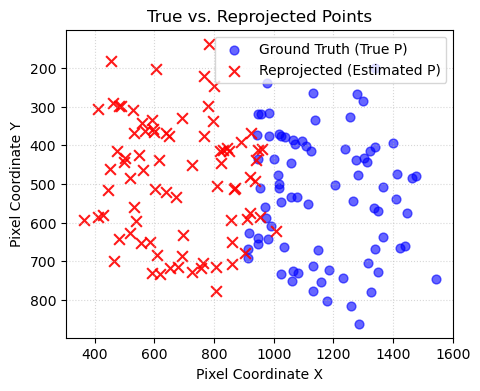

In [3]:
# 1 Génération de la scène 
bounds = np.array([-5, 5, -5, 5, 10, 20])
pts3d = PointsGenerator(nbPoints=80, seed=42, bounds=bounds)  

# 2 Définition des caméras 
K = get_K()
R1, t1 = np.eye(3), np.zeros(3)
R2, t2 = get_camera_pose(rz=10, tz = 4, tx = 4)
norm_t2 = np.linalg.norm(t2)
# 3 Projection 
px1, d1 = project_points(pts3d, K, R1, t1)
px2, d2 = project_points(pts3d, K, R2, t2)

# 4 Filtrage 
vis = filter_visible(px1, d1) & filter_visible(px2, d2)
pts3d_vis = pts3d[:, vis]
print(f"Points visibles dans les deux caméras : {vis.sum()} / {pts3d.shape[1]}")
K_inv = np.linalg.inv(K)
px1_vis = px1[:, vis]
px2_vis = px2[:, vis]

#5 Turn the points to homogenous 2D points
points1 = np.vstack((px1_vis, np.ones((1, px1_vis.shape[1]))))
points2 = np.vstack((px2_vis, np.ones((1, px2_vis.shape[1]))))

# Determine the fundamental matrix and recover the possible extrensic parameters
F = eight_point1(points1.T, points2.T)
print(f"x'^TFx = {points2[:,0].T@F@points1[:,0]}")
t_1, R_1, R_2 = get_R_t_from_F1(F, K)

# Determine the possible projection matrices
P_est = P_estimation(t_1, R_1, R_2, K, norm_t2)

# Determine the reprojection error for each pose
rmse = np.zeros((4, 1))
for i in range(4):
    _, rmse[i], _= reprojection_error(P_est[i, :, :], px2_vis, pts3d_vis)
    print(f"Pose {i} RMSE: {rmse[i, 0]:.2e} px")

# Plot the reprojection points vs true points 
min_idx = np.argmin(rmse)
plot_points_only(px2_vis, pts3d_vis, P_est[min_idx,:,:], title="True vs. Reprojected Points")


# Core functions for essential matrix

In [4]:
def eight_point1_E(points1, points2, K1, K2):
    """
    Function to execute the normalized 8-points algorithm to determine the essential matrix E
    Input:
        - points1: 2D homogenous points of the first image - pixel coordinates (np.array of size Nx3)
        - points2: 2D homogenous points of the second image - pixel coordinates (np.array of size Nx3)
        - K1: Intrinsic parameter of the first camera (np.array of size 3x3)
        - K2: Intrinsic parameter of the second camera (np.array of size 3x3)
    Output:
        - E: Fundamental matrix (np.array 3x3)
    """

    # Convert pixel coordinates to cartesian coordinates
    K1_inv = np.linalg.inv(K1)
    K2_inv = np.linalg.inv(K2)
    points1 = K1_inv@points1.T
    points2 = K2_inv@points2.T

    #1: Normalization: increase stability
    T1 = normalize(points1) # Normalzation matrix
    T2 = normalize(points2)
    norm1 = (T1 @ points1).T
    norm2 = (T2 @ points2).T

    #2: Find the essential matrix of the normalized points
    A_hat = linear_eq(norm1, norm2)
    U, Sigma, V = np.linalg.svd(A_hat)
    E_hat = V[8, :].reshape(3, 3)

    #3: Replace E_hat but Eprime_hat such that det Eprime_hat = 0
    U1, Sigma1, V1 = np.linalg.svd(E_hat)
    Sigma1[2] = 0
    Eprime_hat = U1@np.diag(Sigma1)@V1
    
    #4: Minimize algebraic error and denormalize
    E_hat_opt = min_alg_error(Eprime_hat, A_hat)
    E = T2.T@E_hat_opt@T1

    return E

def get_R_t_from_E(E):
    """
    Function to retrieve the rotational matrix and translational matrix 
    given the essential matrix matrix, assuming P = [I|0] and P' = [R|t]
    Input:
        - E: Fundamental matrix (3x3, np.array)
    Ouput:
        - t:  Translational matrix
        - R1: Rotational matrix (option 1)
        - R2: Rotational matrix (option 2)
    """

    # Standard orthogonal matrices used for decomposing E
    W = np.array([
        [0, -1, 0],
        [1, 0, 0],
        [0, 0, 1]
    ])

    # Decompose the Essential matrix
    U, S, Vh = np.linalg.svd(E)
    print(f"Sigma = {S}")

    # The translation is the last column of U (left null space)
    t = U[:, 2].reshape(-1, 1) 
    
    # Two possible rotation matrices
    R1 = U@W@Vh
    R2 = U@W.T@Vh

    # Ensure they are valid rotation matrices (det = +1, not -1, to prevent reflections)
    if np.linalg.det(R1) < 0: R1 = -R1
    if np.linalg.det(R2) < 0: R2 = -R2
    
    return t, R1, R2

# Essential matrix method

Points visibles dans les deux caméras : 80 / 80
x'^TEx = -0.0010114246097158164
Sigma = [2.89531383e+00 2.87450927e+00 3.91140098e-18]
Pose 0 RMSE: 2.04e+00 px
Pose 1 RMSE: 6.80e+02 px
Pose 2 RMSE: 8.49e+04 px
Pose 3 RMSE: 3.14e+04 px


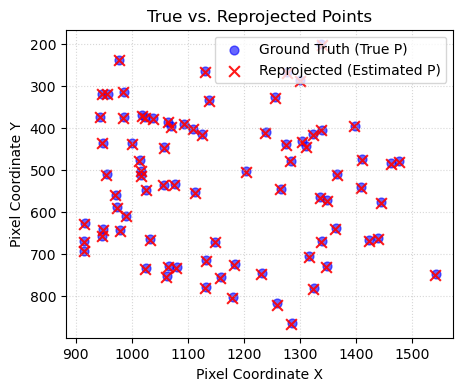

In [5]:
# 1 Génération de la scène 
bounds = np.array([-5, 5, -5, 5, 10, 20])
pts3d = PointsGenerator(nbPoints=80, seed=42, bounds=bounds)  

# 2 Définition des caméras 
K = get_K()
R1, t1 = np.eye(3), np.zeros(3)
R2, t2 = get_camera_pose(rz=10, tz = 4, tx = 4)
norm_t2 = np.linalg.norm(t2)
K_inv = np.linalg.inv(K)
# 3 Projection 
px1, d1 = project_points(pts3d, K, R1, t1)
px2, d2 = project_points(pts3d, K, R2, t2)

# 4 Filtrage 
vis = filter_visible(px1, d1) & filter_visible(px2, d2)
pts3d_vis = pts3d[:, vis]
print(f"Points visibles dans les deux caméras : {vis.sum()} / {pts3d.shape[1]}")
K_inv = np.linalg.inv(K)
px1_vis = px1[:, vis]
px2_vis = px2[:, vis]

#5 Turn the points to homogenous 2D points
points1 = np.vstack((px1_vis, np.ones((1, px1_vis.shape[1]))))
points2 = np.vstack((px2_vis, np.ones((1, px2_vis.shape[1]))))

# Determine the essential matrix and recover the possible extrensic parameters
E = eight_point1_E(points1.T, points2.T, K, K)
print(f"x'^TEx = {(K_inv@points2[:,0]).T@E@(K_inv@points1[:,0])}")
t_1, R_1, R_2 = get_R_t_from_E(E)

# Determine the possible projection matrices
P_est = P_estimation(t_1, R_1, R_2, K, norm_t2)

# Determine the reprojection error for each pose
rmse = np.zeros((4, 1))
for i in range(4):
    _, rmse[i], _= reprojection_error(P_est[i, :, :], px2_vis, pts3d_vis)
    print(f"Pose {i} RMSE: {rmse[i, 0]:.2e} px")

# Plot the reprojection points vs true points 
min_idx = np.argmin(rmse)
plot_points_only(px2_vis, pts3d_vis, P_est[min_idx,:,:], title="True vs. Reprojected Points")